In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7,4)

DATA_DIR = "/kaggle/input/finaldataset/dataset"
print("DATA_DIR =", DATA_DIR)


DATA_DIR = /kaggle/input/finaldataset/dataset


In [21]:
train_log = pd.read_csv(os.path.join(DATA_DIR, "train_log.csv"))
test_log  = pd.read_csv(os.path.join(DATA_DIR, "test_log.csv"))


train_log.head()

,object_id,Z,Z_err,EBV,SpecType,English Translation,split,target
0,Dornhoth_fervain_onodrim,3.0490,NaN,0.110,AGN,Trawn Folk (Dwarfs) + northern + Ents (people),split_01,0
1,Dornhoth_galadh_ylf,0.4324,NaN,0.058,SN II,Trawn Folk (Dwarfs) + tree + drinking vessel,split_01,0
2,Elrim_melethril_thul,0.4673,NaN,0.577,AGN,Elves + lover (fem.) + breath,split_01,0
3,Ithil_tobas_rodwen,0.6946,NaN,0.012,AGN,moon + roof + noble maiden,split_01,0
4,Mirion_adar_Druadan,0.4161,NaN,0.058,AGN,"jewel, Silmaril + father + Wild Man",split_01,0


target
0    0.951364
1    0.048636
Name: proportion, dtype: float64


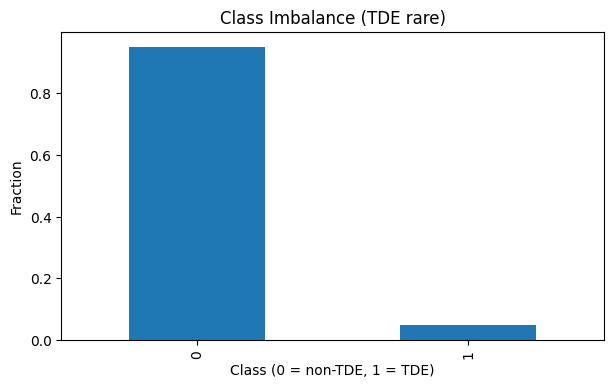

In [22]:
#Class Imbalance
target_frac = train_log["target"].value_counts(normalize=True)
print(target_frac)

target_frac.plot(kind="bar")
plt.title("Class Imbalance (TDE rare)")
plt.ylabel("Fraction")
plt.xlabel("Class (0 = non-TDE, 1 = TDE)")
plt.show()

In [23]:
#Load lightcurves
def load_lightcurves_from_splits(split_ids, kind="train"):
    dfs = []
    for sid in split_ids:
        split_dir = f"split_{sid:02d}"
        file_name = f"{kind}_full_lightcurves.csv"
        path = os.path.join(DATA_DIR, split_dir, file_name)
        if os.path.exists(path):
            dfs.append(pd.read_csv(path))
    return pd.concat(dfs, ignore_index=True)

lc_df = load_lightcurves_from_splits(range(1, 21), kind="train")
print("Loaded lightcurves shape:", lc_df.shape)



Loaded lightcurves shape: (479384, 5)


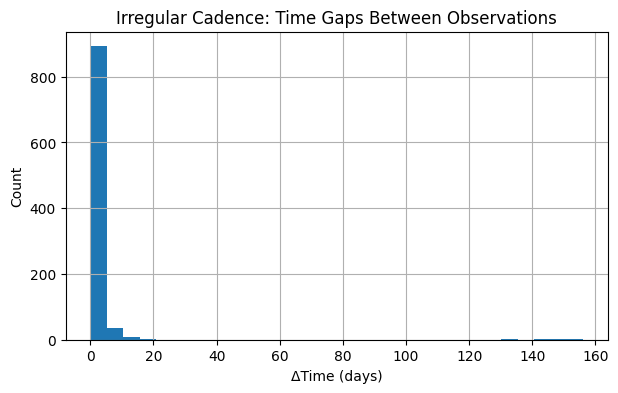

In [24]:
#Observation gaps
obj_id = lc_df["object_id"].sample(1).iloc[0]

obj_df = lc_df[lc_df["object_id"] == obj_id].sort_values("Time (MJD)")
obj_df["dt"] = obj_df["Time (MJD)"].diff()

obj_df["dt"].dropna().hist(bins=30)
plt.title("Irregular Cadence: Time Gaps Between Observations")
plt.xlabel("ΔTime (days)")
plt.ylabel("Count")
plt.show()


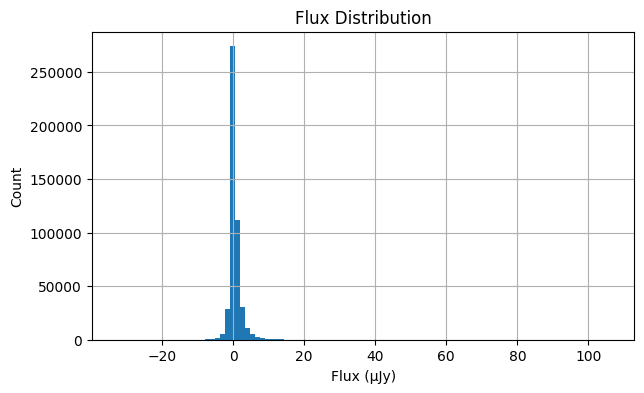

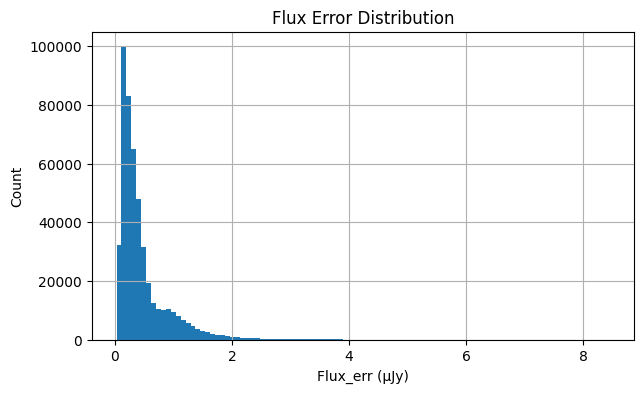

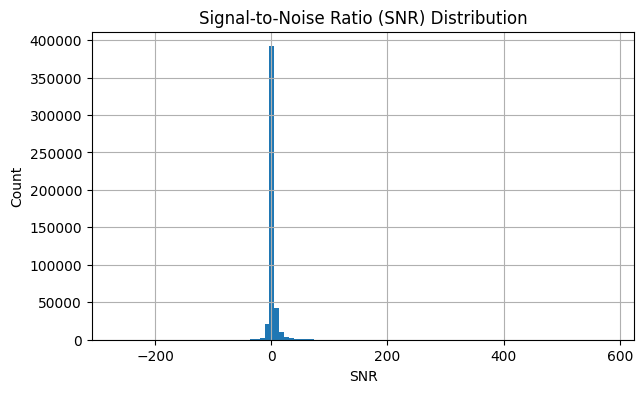

In [32]:


# Flux distribution 
lc_df["Flux"].hist(bins=100)
plt.title("Flux Distribution")
plt.xlabel("Flux (μJy)")
plt.ylabel("Count")
plt.show()

# Flux uncertainty distribution
lc_df["Flux_err"].hist(bins=100)
plt.title("Flux Error Distribution")
plt.xlabel("Flux_err (μJy)")
plt.ylabel("Count")
plt.show()

# Signal-to-noise ratio distribution
snr = lc_df["Flux"] / lc_df["Flux_err"]
snr.hist(bins=100)
plt.title("Signal-to-Noise Ratio (SNR) Distribution")
plt.xlabel("SNR")
plt.ylabel("Count")
plt.show()


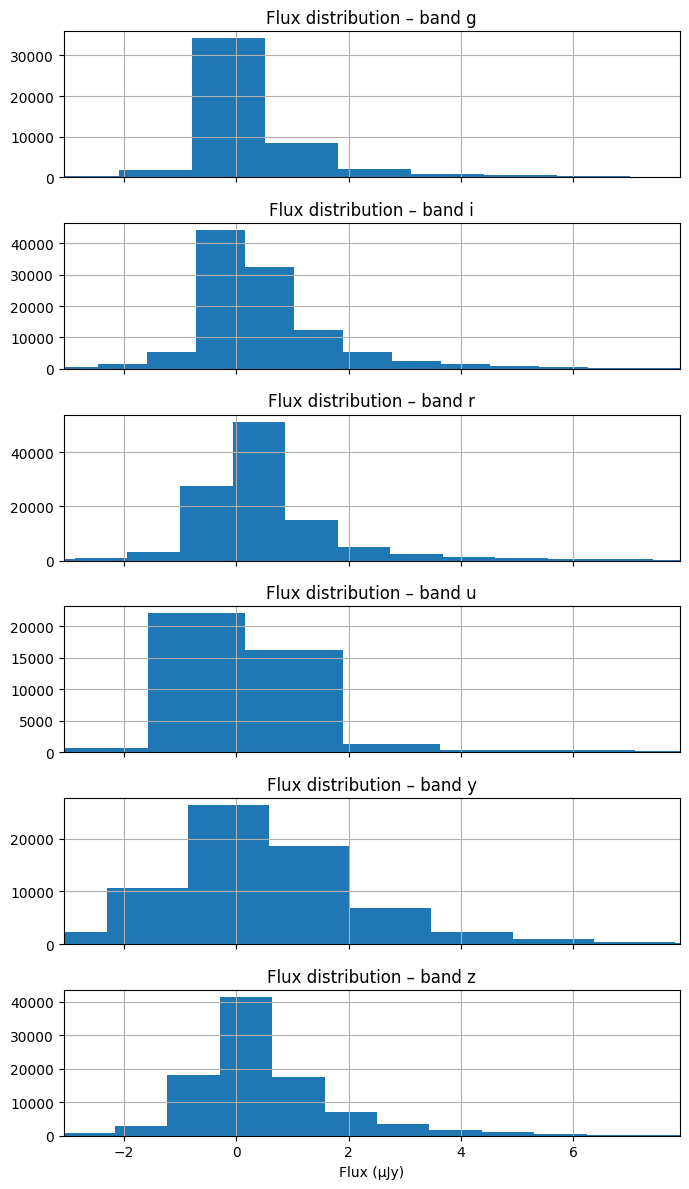

In [35]:
bands = sorted(lc_df["Filter"].unique())

fig, axs = plt.subplots(len(bands), 1, figsize=(7,12), sharex=True)

# Compute global flux range from data (robust)
global_min = lc_df["Flux"].quantile(0.01)
global_max = lc_df["Flux"].quantile(0.99)

for ax, band in zip(axs, bands):
    lc_df[lc_df["Filter"] == band]["Flux"].hist(
        bins=80,
        ax=ax
    )
    ax.set_title(f"Flux distribution – band {band}")
    
    ax.set_xlim(global_min, global_max)

axs[-1].set_xlabel("Flux (μJy)")

plt.tight_layout()
plt.show()

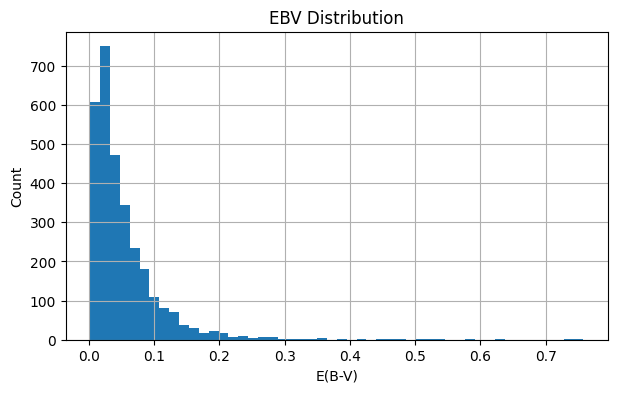

In [29]:
#EBV Distribution
train_log["EBV"].hist(bins=50)
plt.title("EBV Distribution")
plt.xlabel("E(B-V)")
plt.ylabel("Count")
plt.show()


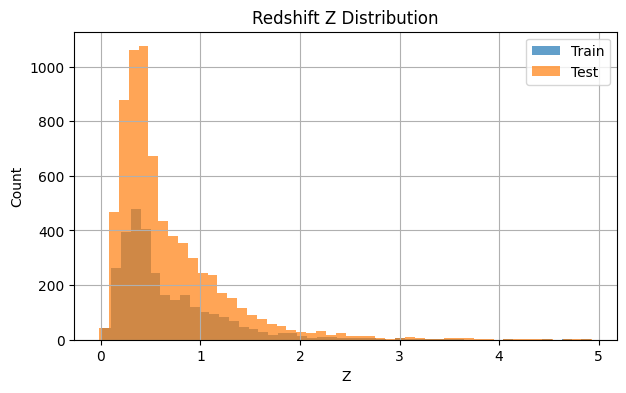

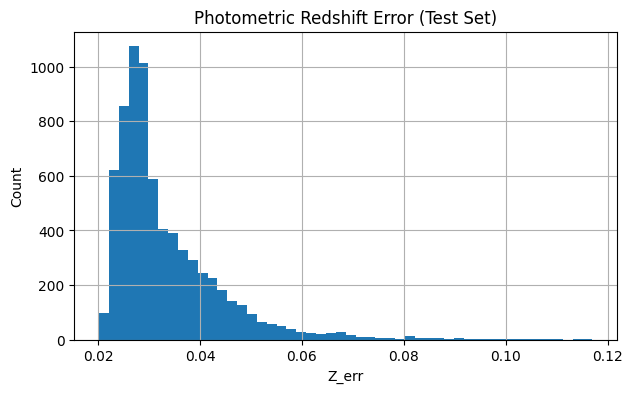

In [19]:
# Z
train_log["Z"].hist(bins=50, alpha=0.7, label="Train")
test_log["Z"].hist(bins=50, alpha=0.7, label="Test")
plt.legend()
plt.title("Redshift Z Distribution")
plt.xlabel("Z")
plt.ylabel("Count")
plt.show()

# Z_err (test only)
test_log["Z_err"].dropna().hist(bins=50)
plt.title("Photometric Redshift Error (Test Set)")
plt.xlabel("Z_err")
plt.ylabel("Count")
plt.show()
